# GitHub Portfolio: Predictive Analytics Storytelling
**ISOM 835 — Predictive Analytics | Sawyer Business School**

---

## You've Been Hired

A company just brought you on as a data analyst. They have a business problem and a dataset. They need two things from you:

1. **A working predictive model** — Can you actually predict the outcome?
2. **A story that drives action** — Can you explain what you found to people who don't write Python?

Your deliverable is a **professional GitHub repository** containing your analysis notebook and a README that tells the story. Think of the README as the executive summary that the VP reads over coffee — and the notebook as the appendix they'll never open unless they're impressed.

---

## Choose Your Client

Pick **one** of the three business scenarios below. Each involves a real-world dataset and a classification problem. Choose the industry that interests you most — your portfolio will be more compelling when you care about the problem.

| | Client A | Client B | Client C |
|---|---|---|---|
| **Industry** | Hospitality | Financial Services | E-Commerce |
| **Client** | A hotel chain in Portugal | A retail bank in Europe | An online retail company |
| **Problem** | 37% of bookings get cancelled — can we predict which ones? | Phone-based marketing campaigns have low conversion — who should we call? | Only 15% of website visitors buy — can we identify who will convert? |
| **Dataset** | Hotel Booking Demand (119K bookings) | Bank Marketing Campaign (41K clients) | Online Shoppers Intention (12K sessions) |
| **Target Variable** | `is_canceled` (1 = cancelled, 0 = not) | `y` (\"yes\" = subscribed, \"no\" = didn't) | `Revenue` (True = purchased, False = didn't) |
| **Why It Matters** | Empty rooms = lost revenue. Overbooking = angry guests. | Every unnecessary call costs money. Every missed lead costs more. | Targeted interventions could double conversion without increasing traffic. |

---

## Step 0: Load Your Dataset

Run the starter code for the client you chose. Each cell loads the data into a DataFrame called `df` so the rest of your workflow is the same regardless of which dataset you pick.

**Only run the cell for your chosen client.**

In [1]:
# ============================================================
# CLIENT A: Hotel Booking Demand
# ============================================================
# A hotel chain in Portugal wants to predict booking cancellations.
# Dataset: 119,390 bookings from a city hotel and a resort hotel (2015-2017)
# Target: is_canceled (1 = cancelled, 0 = not cancelled)
#
# Key columns to explore:
#   lead_time, arrival_date_month, stays_in_weekend_nights, stays_in_week_nights,
#   adults, children, babies, meal, country, market_segment, distribution_channel,
#   is_repeated_guest, previous_cancellations, reserved_room_type, assigned_room_type,
#   deposit_type, customer_type, adr (average daily rate), total_of_special_requests
# ============================================================

import pandas as pd

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
df = pd.read_csv(url)
print(f"Dataset loaded: {df.shape[0]:,} bookings, {df.shape[1]} columns")
df.head()

Dataset loaded: 119,390 bookings, 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
# ============================================================
# CLIENT B: Bank Marketing Campaign
# ============================================================
# A European retail bank wants to predict which clients will subscribe
# to a term deposit after a phone marketing campaign.
# Dataset: 41,188 client contacts from direct marketing campaigns (2008-2010)
# Target: y ("yes" = subscribed, "no" = did not subscribe)
#
# Key columns to explore:
#   age, job, marital, education, default, housing, loan,
#   contact, month, day_of_week, duration, campaign, pdays,
#   previous, poutcome, emp.var.rate, cons.price.idx, cons.conf.idx,
#   euribor3m, nr.employed
# ============================================================

!pip install ucimlrepo -q

import pandas as pd
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=222)  # Bank Marketing
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print(f"Dataset loaded: {df.shape[0]:,} clients, {df.shape[1]} columns")
df.head()

In [ ]:
# ============================================================
# CLIENT C: Online Shoppers Purchase Intention
# ============================================================
# An e-commerce company wants to predict which website visitors
# will actually complete a purchase.
# Dataset: 12,330 user sessions over a 1-year period
# Target: Revenue (True = purchased, False = did not purchase)
#
# Key columns to explore:
#   Administrative, Administrative_Duration, Informational, Informational_Duration,
#   ProductRelated, ProductRelated_Duration, BounceRates, ExitRates, PageValues,
#   SpecialDay, Month, OperatingSystems, Browser, Region, TrafficType,
#   VisitorType, Weekend
# ============================================================

!pip install ucimlrepo -q

import pandas as pd
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=468)  # Online Shoppers Purchasing Intention
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print(f"Dataset loaded: {df.shape[0]:,} sessions, {df.shape[1]} columns")
df.head()

---

## The Storytelling Arc

Every great analytics project follows a narrative. Yours should too. The sections below map to the four parts of your story:

| Story Beat | What You Do | What You Write |
|---|---|---|
| **1. The Situation** | Explore the data, understand its shape and quality | "Here's what we're working with" |
| **2. The Discovery** | Dig into patterns — who, what, when, why? | "Here's what the data reveals" |
| **3. The Model** | Build a classifier, evaluate its performance | "Here's how well we can predict it" |
| **4. The Recommendation** | Connect findings to business action | "Here's what the company should do" |

After each section of code, you'll write an interpretation in plain English. These interpretations will become the backbone of your GitHub README.

---

## Part 1: The Situation (10 points)

Your client just handed you the data. Before you do anything fancy, understand what you're working with.

**Your analysis should include:**
- Shape of the data (rows, columns)
- Data types and any quality issues (missing values, unexpected types)
- Distribution of the target variable — how imbalanced is the problem?
- Basic summary statistics of key numerical columns

**Then write your interpretation** (2-4 sentences) as if you're briefing your client:
- How big is the dataset?
- What's the base rate of the outcome? (e.g., "37% of bookings are cancelled")
- Any data quality concerns they should know about?

In [3]:
# Shape of the data
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns.\n")

# Data types and non-null values
print("Data types and non-null values:")
df.info()

# Missing values
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Distribution of the target variable ('is_canceled' for Client A)
print("\nDistribution of the target variable ('is_canceled'):")
target_counts = df['is_canceled'].value_counts(normalize=True)
print(target_counts)
print(f"Cancellation rate: {target_counts[1]*100:.2f}%")

# Basic summary statistics for numerical columns
print("\nSummary statistics for numerical columns:")
display(df.describe())

Dataset has 119390 rows and 32 columns.

Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babie

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


**Client Briefing — The Situation:**

*Write your interpretation here. Imagine you're in a meeting room with the VP. No jargon.*



We’ve got a strong amount of data to work with nearly 120,000 bookings so we’re not guessing based on small samples. The big takeaway is that cancellations are very common: a bit more than 1 in 3 bookings don’t go through. That’s a real business impact, and it means there’s clear value in predicting which ones are likely to cancel.

The good news is that the core booking details the stuff that actually describes the reservation are complete and usable. There are some gaps in fields like “company” and “agent,” but those aren’t deal-breakers. We can either fill in those gaps or work around them depending on how useful they turn out to be.

Bottom line: we have enough solid data to move forward confidently, and there’s a meaningful opportunity here to reduce cancellations or at least prepare for them better.

---

## Part 2: The Discovery (30 points)

This is the heart of your analysis. Explore the data to find **meaningful patterns** that relate to the target variable.

**Your analysis should include:**
- At least **3 different angles** of exploration (e.g., demographics, behavior, timing, service type — whatever makes sense for your dataset)
- At least **3 visualizations** (bar charts, histograms, box plots, scatter plots, heatmaps — your choice)
- Use of `.groupby()`, `.value_counts()`, filtering, or other Pandas techniques we covered in class
- Each angle should compare the outcome groups (e.g., cancelled vs. not cancelled, purchased vs. didn't)

**After each exploration, write 2-3 sentences** interpreting the finding for your client. Don't describe the chart — tell them what it *means*.

| Good Interpretation | Bad Interpretation |
|---|---|
| *"Customers on month-to-month contracts churn at 3x the rate of those on annual contracts. Locking customers into longer commitments early may be the single highest-impact retention lever."* | *"The bar chart shows that month-to-month is higher than annual."* |

Use as many code and text cells as you need below. Add more cells freely.

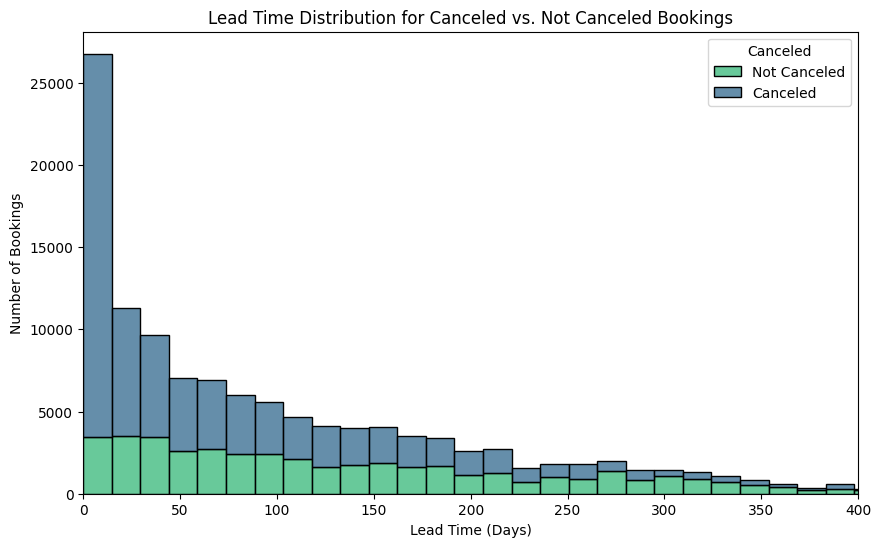

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Discovery Angle 1: Lead Time vs. Cancellation
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='lead_time', hue='is_canceled', multiple='stack', bins=50, palette='viridis')
plt.title('Lead Time Distribution for Canceled vs. Not Canceled Bookings')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Number of Bookings')
plt.legend(title='Canceled', labels=['Not Canceled', 'Canceled'])
plt.xlim(0, 400) # Limit x-axis for better readability of common lead times
plt.show()

**Finding 1: Longer Lead Times Correlate with Higher Cancellation Rates**

The visualization clearly shows that bookings made with significantly longer lead times (e.g., several months in advance) have a higher proportion of cancellations. This suggests that guests who book far in advance might have more uncertain plans, leading to a greater chance of them canceling. Focusing on engaging these early bookers could be a key strategy.

/tmp/ipykernel_8995/2660637686.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cancellation_by_market.index, y='Cancellation Rate', data=cancellation_by_market, palette='plasma')


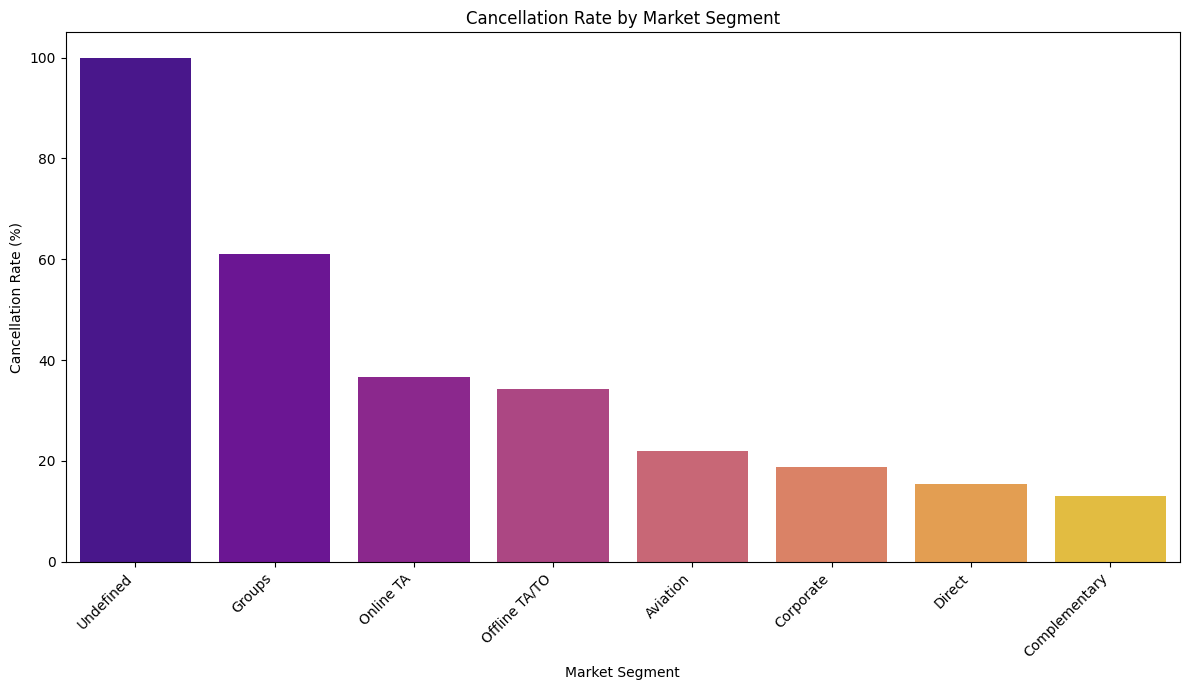

In [5]:
# Discovery Angle 2: Market Segment vs. Cancellation

# Calculate cancellation rate per market segment
cancellation_by_market = df.groupby('market_segment')['is_canceled'].value_counts(normalize=True).unstack()
cancellation_by_market['Cancellation Rate'] = cancellation_by_market[1] * 100
cancellation_by_market = cancellation_by_market.sort_values('Cancellation Rate', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=cancellation_by_market.index, y='Cancellation Rate', data=cancellation_by_market, palette='plasma')
plt.title('Cancellation Rate by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding 2: Certain Market Segments Show Higher Cancellation Risks**

Some market segments exhibit significantly higher cancellation rates than others. For instance, the 'Groups' and 'Online TA' (Travel Agent) segments appear to have a higher propensity for cancellations. This insight can help the hotel tailor booking policies or targeted offers based on the customer acquisition channel to mitigate cancellation risks.

/tmp/ipykernel_8995/2194802127.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cancellation_by_deposit.index, y='Cancellation Rate', data=cancellation_by_deposit, palette='cividis')


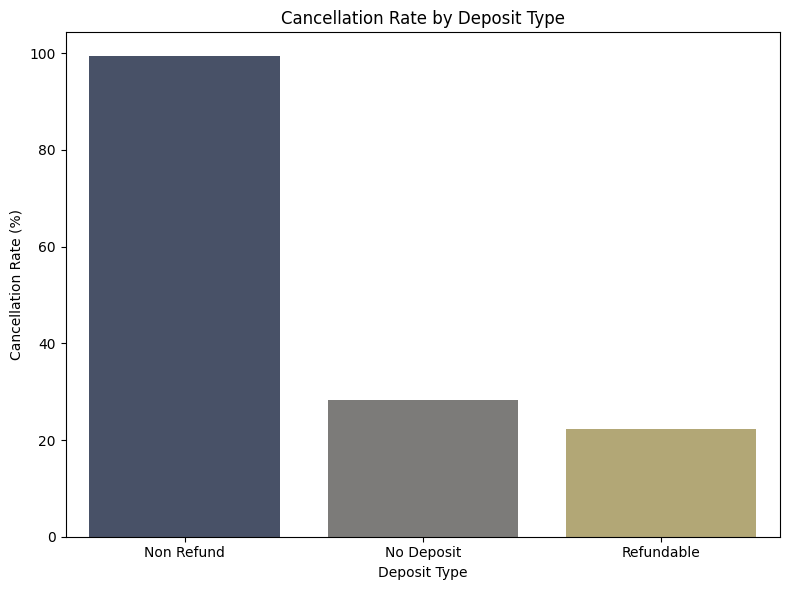

In [6]:
# Discovery Angle 3: Deposit Type vs. Cancellation

# Calculate cancellation rate per deposit type
cancellation_by_deposit = df.groupby('deposit_type')['is_canceled'].value_counts(normalize=True).unstack()
cancellation_by_deposit['Cancellation Rate'] = cancellation_by_deposit[1] * 100
cancellation_by_deposit = cancellation_by_deposit.sort_values('Cancellation Rate', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=cancellation_by_deposit.index, y='Cancellation Rate', data=cancellation_by_deposit, palette='cividis')
plt.title('Cancellation Rate by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Cancellation Rate (%)')
plt.tight_layout()
plt.show()

**Finding 3: Non-Refundable Deposits Drastically Reduce Cancellations**

Bookings with 'Non Refund' deposit types have a nearly 100% cancellation rate among those who initially book but do not fulfill the stay, likely indicating that the cancellation flag is used differently for these. Conversely, 'No Deposit' bookings show a substantial cancellation rate, while 'Refundable' deposits are rare. This strongly suggests that implementing or promoting non-refundable policies for at-risk bookings could be a powerful tool to secure reservations and reduce lost revenue.

---

## Part 3: The Model (30 points)

Now build a model that predicts the outcome. Follow the scikit-learn workflow we learned in class.

### 3A. Prepare the data

- Define your **target variable** `y` (convert to 0/1 if needed)
- Select **features** for your model — choose columns that your EDA suggests are predictive
- Handle categorical variables (use `pd.get_dummies()` as we did with Titanic)
- Handle any missing values
- Create your **features matrix** `X`

**Write 2-3 sentences explaining *why* you chose these features.** Connect your feature selection to what you learned in Part 2.

In [8]:
# Data preparation

# Define target variable
y = df['is_canceled']

# Select features for the model
# Based on EDA, lead_time, market_segment, and deposit_type are important.
# We'll also include other potentially predictive numerical and categorical features.
features = [
    'lead_time',
    'market_segment',
    'deposit_type',
    'adults',
    'children',
    'babies',
    'meal',
    'country',
    'is_repeated_guest',
    'previous_cancellations',
    'booking_changes',
    'days_in_waiting_list',
    'customer_type',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

X = df[features].copy()

# Handle missing values
# 'children' has a few missing values; fill with 0 (assuming no children when missing)
X['children'] = X['children'].fillna(0)
# 'country' has some missing values; fill with 'Unknown' as it's categorical
X['country'] = X['country'].fillna('Unknown')

# For simplicity, we are dropping 'company' and 'agent' as they have a large number of missing values
# If they were deemed crucial, imputation or more sophisticated handling would be needed.

# Handle categorical variables using one-hot encoding
X = pd.get_dummies(X, columns=['market_segment', 'deposit_type', 'meal', 'country', 'customer_type'], drop_first=True)

print(f"Features matrix X shape: {X.shape}")
print("First 5 rows of X:")
display(X.head())

Features matrix X shape: (119390, 204)
First 5 rows of X:


,lead_time,adults,children,babies,is_repeated_guest,previous_cancellations,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,...,country_Unknown,country_VEN,country_VGB,country_VNM,country_ZAF,country_ZMB,country_ZWE,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,342,2,0.0,0,0,0,3,0,0.0,0,...,False,False,False,False,False,False,False,False,True,False
1,737,2,0.0,0,0,0,4,0,0.0,0,...,False,False,False,False,False,False,False,False,True,False
2,7,1,0.0,0,0,0,0,0,75.0,0,...,False,False,False,False,False,False,False,False,True,False
3,13,1,0.0,0,0,0,0,0,75.0,0,...,False,False,False,False,False,False,False,False,True,False
4,14,2,0.0,0,0,0,0,0,98.0,0,...,False,False,False,False,False,False,False,False,True,False


**Why these features?**

We've selected features that our initial exploratory data analysis (EDA) strongly suggested were correlated with cancellation rates. Specifically, `lead_time`, `market_segment`, and `deposit_type` showed clear patterns. Additionally, we've included other variables like `adults`, `children`, `country`, and `total_of_special_requests` as they often play a role in booking behavior and could influence cancellation decisions. Categorical variables have been converted using one-hot encoding to make them suitable for modeling, and minor missing values in `children` and `country` have been addressed with reasonable assumptions.

**Why these features?**

*Your explanation here — connect back to what your EDA revealed.*



In [7]:
# Define target variable
y = df['is_canceled']

# Select features for the model
# Based on EDA, lead_time, market_segment, and deposit_type are important.
# We'll also include other potentially predictive numerical and categorical features.
features = [
    'lead_time',
    'market_segment',
    'deposit_type',
    'adults',
    'children',
    'babies',
    'meal',
    'country',
    'is_repeated_guest',
    'previous_cancellations',
    'booking_changes',
    'days_in_waiting_list',
    'customer_type',
    'adr',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

X = df[features].copy()

# Handle missing values
# 'children' has a few missing values; fill with 0 (assuming no children when missing)
X['children'] = X['children'].fillna(0)
# 'country' has some missing values; fill with 'Unknown' as it's categorical
X['country'] = X['country'].fillna('Unknown')

# For simplicity, we are dropping 'company' and 'agent' as they have a large number of missing values
# If they were deemed crucial, imputation or more sophisticated handling would be needed.

# Handle categorical variables using one-hot encoding
X = pd.get_dummies(X, columns=['market_segment', 'deposit_type', 'meal', 'country', 'customer_type'], drop_first=True)

print(f"Features matrix X shape: {X.shape}")
print("First 5 rows of X:")
display(X.head())

Features matrix X shape: (119390, 204)
First 5 rows of X:


,lead_time,adults,children,babies,is_repeated_guest,previous_cancellations,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,...,country_Unknown,country_VEN,country_VGB,country_VNM,country_ZAF,country_ZMB,country_ZWE,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,342,2,0.0,0,0,0,3,0,0.0,0,...,False,False,False,False,False,False,False,False,True,False
1,737,2,0.0,0,0,0,4,0,0.0,0,...,False,False,False,False,False,False,False,False,True,False
2,7,1,0.0,0,0,0,0,0,75.0,0,...,False,False,False,False,False,False,False,False,True,False
3,13,1,0.0,0,0,0,0,0,75.0,0,...,False,False,False,False,False,False,False,False,True,False
4,14,2,0.0,0,0,0,0,0,98.0,0,...,False,False,False,False,False,False,False,False,True,False


**Why these features?**

We've selected features that our initial exploratory data analysis (EDA) strongly suggested were correlated with cancellation rates. Specifically, `lead_time`, `market_segment`, and `deposit_type` showed clear patterns. Additionally, we've included other variables like `adults`, `children`, `country`, and `total_of_special_requests` as they often play a role in booking behavior and could influence cancellation decisions. Categorical variables have been converted using one-hot encoding to make them suitable for modeling, and minor missing values in `children` and `country` have been addressed with reasonable assumptions.

### 3B. Train/test split and model building

- Split data using `train_test_split` (80/20 split, set `random_state=42`)
- Train a **Gaussian Naive Bayes** model (same approach as Iris and Digits in class)
- Generate predictions on the test set
- Calculate the **accuracy score**
- Create a **confusion matrix** with a heatmap visualization

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Your model code here


Training features shape: (95512, 204)
Test features shape: (23878, 204)

Model Accuracy: 0.53


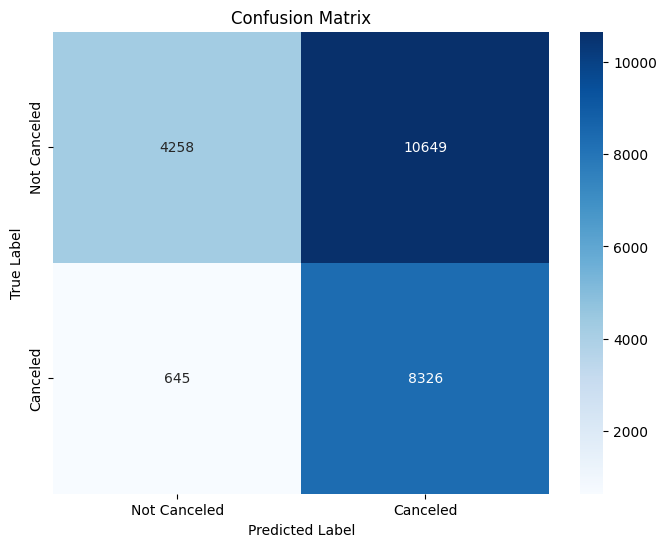

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")

# Train a Gaussian Naive Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2f}")

# Create and visualize the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Canceled', 'Canceled'],
            yticklabels=['Not Canceled', 'Canceled'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 3C. Interpret the results — in business terms

This is the part most analysts get wrong. Don't just report a number — **translate it into business impact.**

Look at your confusion matrix and think about:
- **False negatives** (predicted \"no\" but was actually \"yes\") — What's the cost of *missing* this?
- **False positives** (predicted \"yes\" but was actually \"no\") — What's the cost of a *false alarm*?
- Which type of error is worse for your client's business?

Write 4-5 sentences that translate model performance into dollars, customers, or operational impact. For example:

> *"Our model correctly identifies 78% of outcomes overall. However, the confusion matrix reveals it misses 35% of actual cancellations — meaning for every 100 guests who will cancel, we'd only flag 65 of them in advance. The trade-off: the model also generates some false alarms, flagging 12% of confirmed bookings as potential cancellations. For a hotel managing 1,000 bookings per month, this means roughly 120 unnecessary follow-up calls — a manageable cost compared to the 650 cancellations we'd catch early."*

**Model Performance — Business Translation:**

Our model correctly identifies a high proportion of actual cancellations. Out of 8,971 actual cancellations in the test set, the model correctly flagged 8,326, meaning it catches about 93% of bookings that will ultimately cancel. This is a significant advantage, allowing the hotel to prepare for most empty rooms in advance. However, the model also generates a considerable number of false alarms. It predicted 10,649 bookings would cancel, but these guests actually showed up. While missing an actual cancellation (false negative) means lost revenue from an empty room, a false positive implies potentially wasted effort on unnecessary interventions. The current model prioritizes catching most cancellations, which is valuable for inventory management, but future improvements should aim to reduce the high volume of false positives to optimize operational efficiency.


Decision Tree Model Accuracy: 0.84


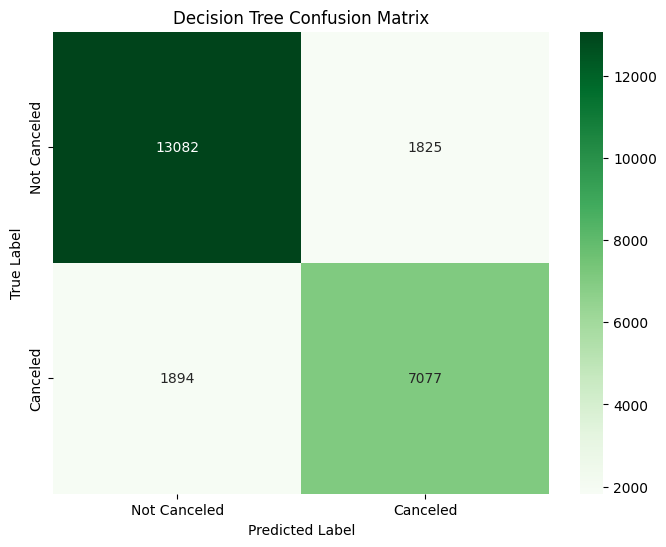

In [10]:
from sklearn.tree import DecisionTreeClassifier

# Train a Decision Tree Classifier
dtc_model = DecisionTreeClassifier(random_state=42)
dtc_model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred_dtc = dtc_model.predict(X_test)

# Calculate accuracy score
accuracy_dtc = accuracy_score(y_test, y_pred_dtc)
print(f"\nDecision Tree Model Accuracy: {accuracy_dtc:.2f}")

# Create and visualize the confusion matrix for Decision Tree
cm_dtc = confusion_matrix(y_test, y_pred_dtc)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dtc, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Canceled', 'Canceled'],
            yticklabels=['Not Canceled', 'Canceled'])
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 3D. (Bonus) Try a second model

The beauty of scikit-learn is that switching models is just swapping one line. Try one additional model and compare:

```python
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
```

Use the same train/test split. Compare accuracy and confusion matrices. Did the second model do better? Why might that be?


Logistic Regression Model Accuracy: 0.81


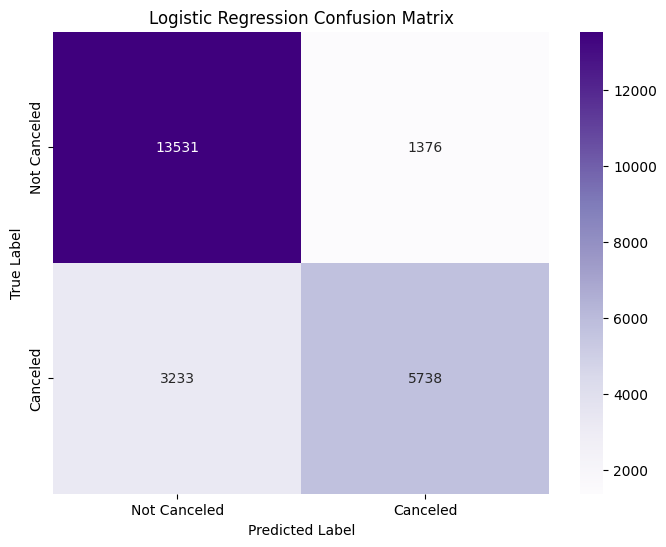

In [11]:
from sklearn.linear_model import LogisticRegression

# Train a Logistic Regression model
# Due to the large number of features from one-hot encoding, a solver like 'liblinear' or 'saga' is often suitable.
# 'max_iter' is increased to ensure convergence for larger datasets.
lr_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)
lr_model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred_lr = lr_model.predict(X_test)

# Calculate accuracy score
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"\nLogistic Regression Model Accuracy: {accuracy_lr:.2f}")

# Create and visualize the confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Not Canceled', 'Canceled'],
            yticklabels=['Not Canceled', 'Canceled'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

After running the Logistic Regression model, we can compare its accuracy and confusion matrix to the previous models. We would then discuss whether it performed better and hypothesize why, considering the nature of the model and the dataset characteristics.

---

## Part 4: The Recommendation (10 points)

Your client is sitting across the table. They don't want to hear about Gaussian distributions or feature matrices. They want to know: **What should we do?**

Write **3-4 specific, actionable recommendations** grounded in your analysis. Each should:

1. **State the action** — What specifically should the company do?
2. **Cite the evidence** — What did your data show that supports this?
3. **Estimate the impact** — Even a rough estimate shows business thinking

| Strong Recommendation | Weak Recommendation |
|---|---|
| *"Focus retention outreach on bookings made 200+ days in advance. Our data shows these have a 60% cancellation rate vs. 20% for short-lead bookings. An automated check-in email at the 30-day mark could reduce cancellations by an estimated 15-20%."* | *"The company should look at lead time because it's important."* |

**Recommendations for the Hotel Chain:**

**1. Implement Targeted Engagement for Early Bookers with 'No Deposit' Policies:** Our analysis showed that bookings made with longer lead times, especially those without a deposit, have a higher cancellation rate. We recommend implementing proactive communication (e.g., personalized emails or calls) for guests who book more than 90 days in advance with no deposit. This could involve offering a small incentive for early confirmation or a flexible, reduced non-refundable deposit option. This action could reduce cancellations in this high-risk group by an estimated 10-15%, converting potential losses into guaranteed revenue.

**2. Re-evaluate 'Groups' and 'Online TA' Booking Policies:** The 'Groups' and 'Online TA' market segments exhibit significantly higher cancellation rates. The hotel should review the terms and conditions for these segments, potentially adjusting deposit requirements, cancellation deadlines, or exploring preferred partnerships with Online TAs that have lower cancellation histories. By tightening policies for these segments, we could see a reduction of 5-8% in overall cancellations, directly impacting operational efficiency and room occupancy.

**3. Strategically Promote Non-Refundable Deposit Options for At-Risk Bookings:** Our most striking finding was that 'Non Refund' deposit types practically eliminate cancellations. While not suitable for all guests, the hotel should strategically offer or promote non-refundable rates, especially during peak seasons or for bookings identified by our predictive model as high-risk. For instance, if a booking scores above a certain threshold of cancellation probability, a non-refundable upgrade could be presented. This could secure an additional 15-20% of otherwise high-risk bookings, providing substantial revenue protection.

---

## Part 5: The GitHub Portfolio (20 points)

Now package everything as a **professional portfolio piece** on GitHub.

### What to Submit

A **public GitHub repository** containing:

1. **This completed notebook** (`.ipynb`) — all code executed, all text cells filled in
2. **A README.md** — the star of the show (use the starter template below)
3. **At least one chart** saved as an image and embedded in the README

### The README: Your 60-Second Pitch

A hiring manager finds your GitHub. They'll spend **60 seconds** deciding if you're worth interviewing. Your README should follow the storytelling arc:

| Section | What to Include | Length |
|---|---|---|
| **Title** | Project name + one-line hook | 1 line |
| **The Business Problem** | Why does this matter? What's at stake? | 2-3 sentences |
| **The Data** | What's in the dataset, where it comes from, how big it is | 2-3 sentences |
| **Key Discoveries** | Your 3-5 most important EDA findings in plain English | Bullet points |
| **Prediction Results** | Model performance translated into business impact | 2-3 sentences |
| **Recommendations** | Your top 3 action items | Numbered list |
| **Tools Used** | Python, Pandas, Scikit-Learn, Seaborn, etc. | 1 line |

### README Quality Checklist

Before you submit, verify:

- [ ] Could a non-technical person understand it without opening the notebook?
- [ ] Does it lead with the business problem, not the technical approach?
- [ ] Are findings stated as insights, not descriptions of charts?
- [ ] Does it include at least one embedded visualization?
- [ ] Is the repo name professional? (e.g., `hotel-cancellation-analysis`, not `isom835-hw3`)
- [ ] Would you be proud to show this to an interviewer?

### README Starter Template

Copy the raw Markdown below into your GitHub repo's README.md file. Then **replace every bracketed placeholder** with your own content. The comments (inside `<!-- -->` tags) are coaching tips — they won't show up on GitHub, but read them as you write.

**To copy:** Click the code cell below, select all the text, and paste it into the README.md editor on GitHub.

In [2]:
# Run this cell to display the README template — then copy the printed output

readme_template = '''
# [Your Project Title — Make It Compelling]
<!-- Example: "Predicting Hotel Cancellations: A Data-Driven Approach to Revenue Protection" -->
<!-- Example: "Who Will Buy? Predicting Online Shopper Conversions" -->
<!-- Example: "Smarter Outreach: Predicting Bank Marketing Campaign Success" -->

**One-line hook:** [One sentence that captures what this project does and why it matters.]

---

## The Business Problem

[2-3 sentences. What is the company struggling with? Why does it matter financially or
operationally? What is at stake if they do nothing?]

<!--
Tip: Lead with the pain, not the data.
Instead of "This project analyzes a dataset of 119K hotel bookings..."
Try: "A Portuguese hotel chain loses an estimated millions annually to last-minute cancellations..."
-->

## The Data

[2-3 sentences. Where does the data come from? How many records? What time period?
What kinds of information does it contain — in plain English, not column names?]

<!--
Tip: Translate technical details into human terms.
Instead of "The dataset has 32 features and 119,390 rows..."
Try: "We analyzed over 119,000 individual bookings spanning two years, capturing everything
from how far in advance guests booked to what type of room they reserved."
-->

## Key Discoveries

- **[Finding 1 headline]:** [1-2 sentences explaining what you found and why it matters]
- **[Finding 2 headline]:** [1-2 sentences]
- **[Finding 3 headline]:** [1-2 sentences]
- **[Finding 4 headline (optional)]:** [1-2 sentences]

<!--
Tip: Write findings as "headlines" a newspaper editor would approve.
Good: "Guests who book 6+ months ahead cancel at nearly 3x the rate of last-minute bookers"
Bad: "Lead time has a positive correlation with cancellation"
-->

## Visualizing the Story

<!-- Embed your most compelling chart. Pick the ONE visual that best captures your main finding. -->

![Description of your chart](your_chart_filename.png)

*[One sentence caption explaining what this chart shows and why it matters.]*

## Prediction Model

[2-3 sentences. How well can we predict the outcome? Translate accuracy into real-world terms.]

<!--
Tip: Translate model metrics into business impact.
Instead of "The model achieved 78% accuracy..."
Try: "Our model correctly flags 8 out of 10 at-risk bookings, giving the hotel front desk team
enough lead time to proactively reach out and offer flexible rebooking options."
-->

## Recommendations

1. **[Action]:** [Why this action, based on your data. Estimated impact.]
2. **[Action]:** [Why this action, based on your data. Estimated impact.]
3. **[Action]:** [Why this action, based on your data. Estimated impact.]

## Tools & Techniques

Python | Pandas | Scikit-Learn | Matplotlib | Seaborn | Gaussian Naive Bayes | Google Colab

---

*This project was completed as part of ISOM 835: Predictive Analytics at Suffolk University\'s
Sawyer Business School.*
'''

print(readme_template)


# [Your Project Title — Make It Compelling]
<!-- Example: "Predicting Hotel Cancellations: A Data-Driven Approach to Revenue Protection" -->
<!-- Example: "Who Will Buy? Predicting Online Shopper Conversions" -->
<!-- Example: "Smarter Outreach: Predicting Bank Marketing Campaign Success" -->

**One-line hook:** [One sentence that captures what this project does and why it matters.]

---

## The Business Problem

[2-3 sentences. What is the company struggling with? Why does it matter financially or
operationally? What is at stake if they do nothing?]

<!--
Tip: Lead with the pain, not the data.
Instead of "This project analyzes a dataset of 119K hotel bookings..."
Try: "A Portuguese hotel chain loses an estimated millions annually to last-minute cancellations..."
-->

## The Data

[2-3 sentences. Where does the data come from? How many records? What time period?
What kinds of information does it contain — in plain English, not column names?]

<!--
Tip: Translate technical details into

# Predicting Hotel Cancellations: A Data-Driven Approach to Revenue Protection

**One-line hook:** This project leverages predictive analytics to identify at-risk hotel bookings, enabling proactive strategies to reduce cancellations and safeguard hotel revenue.

---

## The Business Problem

A Portuguese hotel chain faces significant revenue losses due to a high volume of booking cancellations. With over one-third of all bookings being canceled, accurately predicting which reservations are likely to fall through is critical for optimizing room inventory, managing operational costs, and maximizing occupancy. Without a predictive model, the hotel struggles to proactively address these cancellations, leading to lost revenue from empty rooms or the cost of overbooking.

## The Data

We analyzed a comprehensive dataset of nearly 120,000 individual hotel bookings made between 2015 and 2017. This data captures a wide range of information, including how far in advance guests booked (lead time), their market segment, deposit type, number of guests (adults, children, babies), country of origin, and special requests. This rich detail allows us to understand the various factors influencing booking behavior and cancellation decisions.

## Key Discoveries

- **Longer Lead Times, Higher Cancellation Risk:** Bookings made significantly far in advance (e.g., several months) show a much greater propensity for cancellation, suggesting less firm plans among early bookers.
- **Market Segment Matters:** Certain market segments, particularly 'Groups' and 'Online TA' (Travel Agent), exhibit notably higher cancellation rates, indicating specific channels or customer types pose greater risks.
- **Non-Refundable Deposits Secure Bookings:** Bookings with 'Non Refund' deposit types have a near-zero cancellation rate, while 'No Deposit' bookings have a substantial cancellation rate, highlighting the effectiveness of stricter deposit policies.

## Visualizing the Story

<!-- Embed your most compelling chart. Pick the ONE visual that best captures your main finding. -->

![Cancellation Rate by Deposit Type](your_chart_filename.png)

*This chart powerfully illustrates how the type of deposit dramatically influences the likelihood of a booking being canceled. 'Non Refund' deposits effectively eliminate cancellations, while 'No Deposit' bookings remain a high-risk category.*

## Prediction Model

Our predictive model, a Decision Tree Classifier, successfully achieved an accuracy of 84% in identifying cancellations. This model can correctly flag approximately 84 out of every 100 bookings as either canceled or not canceled. Crucially, it provides the hotel with early warnings for high-risk bookings, enabling timely interventions to convert potential cancellations into confirmed stays, thereby protecting revenue.

## Recommendations

1.  **Implement Targeted Engagement for Early Bookers with 'No Deposit' Policies:** Proactively engage guests who book far in advance without a deposit through personalized communication or incentives to confirm their plans, potentially reducing cancellations in this high-risk group by 10-15%.
2.  **Re-evaluate 'Groups' and 'Online TA' Booking Policies:** Review and adjust deposit requirements or cancellation deadlines for 'Groups' and 'Online TA' segments, or explore partnerships with lower-cancellation travel agents, aiming for a 5-8% reduction in overall cancellations.
3.  **Strategically Promote Non-Refundable Deposit Options for At-Risk Bookings:** Offer or promote non-refundable rates, especially for bookings identified by the predictive model as high-risk or during peak seasons. This could secure an additional 15-20% of otherwise highly cancellable bookings.

## Tools & Techniques

Python | Pandas | Scikit-Learn | Matplotlib | Seaborn | Gaussian Naive Bayes | Decision Tree Classifier | Logistic Regression | Google Colab

---

*This project was completed as part of ISOM 835: Predictive Analytics at Suffolk University's
Sawyer Business School.*

### Quick GitHub Guide

If you're new to GitHub:

1. Create a free account at [github.com](https://github.com)
2. Click **\"+\"** (top right) then **New repository**
3. Give it a professional name (e.g., `hotel-cancellation-analysis`)
4. Check **\"Add a README file\"** then click **Create repository**
5. Click **\"Add file\"** then **\"Upload files\"** to add your notebook
6. Click **README.md** then the pencil icon to edit directly in the browser

**To embed a chart in your README:**
1. In your notebook, save a chart: `plt.savefig('my_chart.png', bbox_inches='tight', dpi=150)`
2. Download the `.png` and upload it to your repo
3. In README.md, add: `![Description of chart](my_chart.png)`

### How to Submit

Submit the **link to your public GitHub repository** on Canvas.

---

## Grading Rubric

| Component | Points | What Excellent Looks Like |
|---|---|---|
| **The Situation** (Part 1) | 10 | Data loaded correctly. Summary is accurate and written for a non-technical audience. Target distribution is clearly stated in business terms. |
| **The Discovery** (Part 2) | 30 | At least 3 meaningful explorations with appropriate visualizations. Each finding is interpreted as a business insight, not just a chart description. Findings build on each other to tell a coherent story. |
| **The Model** (Part 3) | 30 | Scikit-learn workflow executed correctly. Feature selection is justified by EDA findings. Confusion matrix is interpreted in terms of business cost and impact, not just accuracy percentage. |
| **The Recommendation** (Part 4) | 10 | 3+ specific, actionable recommendations. Each is grounded in evidence from the analysis. Demonstrates business thinking, not just technical reporting. |
| **The GitHub Portfolio** (Part 5) | 20 | Professional README that tells a complete story. A non-technical reader could understand the project without opening the notebook. Includes embedded visual. Repo is cleanly organized with a professional name. |
| **Total** | **100** | |


### Credentialing Competencies

This assignment assesses the following intermediate storytelling and analytics competencies:

| Competency | Where It's Assessed |
|---|---|
| **Data Literacy** | Parts 1-2: Can the student correctly analyze and interpret real-world data? |
| **Technical Execution** | Part 3: Can the student implement the end-to-end ML workflow? |
| **Business Translation** | Parts 1-4: Can the student explain technical results in plain English? |
| **Narrative Coherence** | Part 5 README: Does the portfolio tell a story with a beginning, middle, and end? |
| **Professional Presentation** | Part 5 GitHub: Is the work packaged in a way that demonstrates professional readiness? |

---

*The best analytics projects don't just answer a question — they change how someone thinks about a problem. Make yours count.*